# Доступ к LLM по API и базовый инференс

# Шаг 1: Получаем доступ к LLM по API и учимся с ней общаться

## Будем работать с моделями (LLM) через API OpenRouter

OPENROUTER_TOKEN возьмем с сайта openrouter в личном кабинете.

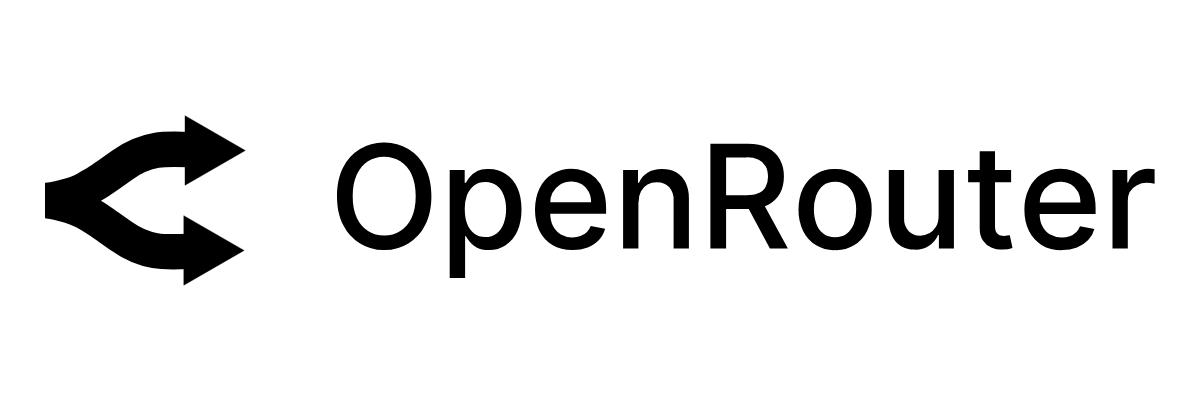

In [ ]:
!pip install langchain langchain-openai langchain_community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 500.5/500.5 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 2.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: langchain-core
    Found existing installation: langchain-core 1.2.12
    Uninstalling langchain-core-1.2.12:
      Successfully uninstalled langchain-core-1.2.12
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google

Подключимся к модели DeepSeek

In [ ]:
OPENROUTER_TOKEN = ""

In [ ]:
from langchain_openai import ChatOpenAI

deepseek_llm = ChatOpenAI(
    api_key=OPENROUTER_TOKEN,
    base_url="https://openrouter.ai/api/v1",
#    model = "openrouter/aurora-alpha"
#    model = "stepfun/step-3.5-flash:free"
    model="deepseek/deepseek-r1-0528:free"
)

deepseek_response = deepseek_llm.invoke("Привет! Как твои дела?").content
print(deepseek_response)

KeyboardInterrupt: 

Пообщаемся с моделью и выясним, есть ли у нее память?

In [ ]:
question1 = "Сколько лап у паука?"
additional_question = "А зубов?"

print(question1)
print(deepseek_llm.invoke(question1).content)
print(additional_question)
print(deepseek_llm.invoke(additional_question).content)

Сколько лап у паука?
У паука восемь лап.
А зубов?
**Зубы — что важно знать о их уходе и здоровье**

1. **Ежедневный уход**  
   - **Чистка**: минимум два раза в день (утром и перед сном) с использованием фторсодержащей зубной пасты.  
   - **Щётка**: выбирайте щётку с мягкой или средней жёсткостью, заменяйте её каждые 3 – 4 мес.  
   - **Флос и междёшечные ершики**: удаляют зубной налёт и частицы пищи в тех местах, где щётка не достаёт.

2. **Питание**  
   - Ограничьте сладкие и кислые продукты/напитки (особенно между приёмами пищи).  
   - Включайте в рацион кальций‑ и витамин D‑богатые продукты (молочные изделия, рыба, листовая зелень).  
   - Пейте достаточно воды  это помогает смыть остатки пищи и поддерживать слюноотделение.

3. **Регулярные осмотры**  
   - **Профилактический осмотр** у стоматолога — каждые 6 месяцев (в некоторых случаях может потребоваться чаще).  
   - Профессиональная гигиена (чистка оттёком) помогает предотвратить кариес и пародонтит.

4. **Признаки проблем*

Оформим диалог красиво

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

question1_message = HumanMessage(content=question1)
additional_question_message = HumanMessage(content=additional_question)

answer1_message = AIMessage(content=deepseek_llm.invoke([question1_message]).content)
answer2_message = AIMessage(content=deepseek_llm.invoke([additional_question_message]).content)

question1_message.pretty_print()
answer1_message.pretty_print()
additional_question_message.pretty_print()
answer2_message.pretty_print()

================================ Human Message =================================

Сколько лап у паука?
================================== Ai Message ==================================

У паука восемь лап.
================================ Human Message =================================

А зубов?
================================== Ai Message ==================================

Зубы — это важная часть пищеварительной системы, а также ключевой элемент внешнего вида и речи. Ниже — кратко о их типах, строении и уходе.

### 1. Типы зубов
| Тип | Количество (у взрослого) | Функция |
|-----|---------------------------|----------|
| Резцы (incisors) | 8 (по 4 сверху и снизу) | Обрезание пищи |
| Клыки (canines) | 4 (по 2 сверху и снизу) | Прокалывание и удержание пищи |
| Премоляры (premolars) | 8 (по 4 сверху и снизу) | Дробление, подготовка к жеванию |
| Моляры (molars) | 12 по 6 сверху и снизу, включая третьи моляры — зубы)) | Дробление и измельчение пищи |

### 2. Строение зуба
- **Коронка**

Памяти - нет. Организуем ее самостоятельно!

In [ ]:
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage

dialogue = []
dialogue.append(question1_message)
dialogue.append(AIMessage(content=deepseek_llm.invoke(dialogue).content))
dialogue.append(additional_question_message)
dialogue.append(AIMessage(content=deepseek_llm.invoke(dialogue).content))

for phrase in dialogue:
    phrase.pretty_print()

================================ Human Message =================================

Сколько лап у паука?
================================== Ai Message ==================================

У паука восемь лап.
================================ Human Message =================================

А зубов?
================================== Ai Message ==================================

У пауков нет «зубов» в том виде, как они есть у млекопитающих. Вместо этого у них есть пара хелличесеров (жевательных придатков), на конце которых находятся клыки‑жвом « f каждый использоваться для укола и введения яда, а также для разрывания добычи. Иногда на внутренней поверхности хелличесеров могут быть небольшие зубчатые отростки, но это не настоящие зубы. Поэтому в привычном смысле у паука «зубов» нет.
